In [21]:
import kagglehub
import os
import shutil
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing import image

path = kagglehub.dataset_download("nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ct-kidney-dataset-normal-cyst-tumor-and-stone' dataset.
Path to dataset files: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone


In [3]:
# Ensure dataset_path is defined if the previous cell was not run or kernel reset
dataset_path = path
# Construct the full path to the parent directory containing the case folders
parent_dir = os.path.join(dataset_path, "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone", "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone")

# Define paths for each case type
normal_cases_path = os.path.join(parent_dir, "Normal")
cyst_cases_path = os.path.join(parent_dir, "Cyst")
tumor_cases_path = os.path.join(parent_dir, "Tumor")
stone_cases_path = os.path.join(parent_dir, "Stone")

# Print the paths to verify
print(f"Normal cases path: {normal_cases_path}")
print(f"Cyst cases path: {cyst_cases_path}")
print(f"Tumor cases path: {tumor_cases_path}")
print(f"Stone cases path: {stone_cases_path}")

Normal cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal
Cyst cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst
Tumor cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Tumor
Stone cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Stone


In [4]:
# Menghitung jumlah file di setiap folder
num_normal = len(os.listdir(normal_cases_path))
num_cyst = len(os.listdir(cyst_cases_path))
num_tumor = len(os.listdir(tumor_cases_path))
num_stone = len(os.listdir(stone_cases_path))

# Menampilkan hasil
print(f"Jumlah data Awal :")
print(f"Jumlah data Normal: {num_normal}")
print(f"Jumlah data Cyst: {num_cyst}")
print(f"Jumlah data Tumor: {num_tumor}")
print(f"Jumlah data Stone: {num_stone}")

# Menghitung total keseluruhan
total_data = num_normal + num_cyst + num_tumor + num_stone
print(f"\nTotal seluruh data: {total_data}")

Jumlah data Awal :
Jumlah data Normal: 5077
Jumlah data Cyst: 3709
Jumlah data Tumor: 2283
Jumlah data Stone: 1377

Total seluruh data: 12446


In [5]:
import os

# Disarankan menggunakan sorted() agar urutan file yang diambil selalu konsisten
normal_1000 = sorted(os.listdir(normal_cases_path))[:1000]
cyst_1000   = sorted(os.listdir(cyst_cases_path))[:1000]
tumor_1000  = sorted(os.listdir(tumor_cases_path))[:1000]
stone_1000  = sorted(os.listdir(stone_cases_path))[:1000]

# Jika kamu butuh path lengkap (full path) dari setiap gambarnya:
normal_paths = [os.path.join(normal_cases_path, f) for f in normal_1000]
cyst_paths   = [os.path.join(cyst_cases_path, f) for f in cyst_1000]
tumor_paths  = [os.path.join(tumor_cases_path, f) for f in tumor_1000]
stone_paths  = [os.path.join(stone_cases_path, f) for f in stone_1000]

# Cek jumlah data yang berhasil diambil
print(f"Data Normal yang diambil: {len(normal_paths)}")
print(f"Data Cyst yang diambil: {len(cyst_paths)}")
print(f"Data Tumor yang diambil: {len(tumor_paths)}")
print(f"Data Stone yang diambil: {len(stone_paths)}")

Data Normal yang diambil: 1000
Data Cyst yang diambil: 1000
Data Tumor yang diambil: 1000
Data Stone yang diambil: 1000


In [6]:
# 1. Buat folder baru untuk menyimpan subset dataset
subset_dir = os.path.join("/content/", "Dataset_Subset_1000") # Change dataset_path to a writable location
os.makedirs(subset_dir, exist_ok=True)

# 2. Dictionary dari path sumber
categories = {
  "Normal": normal_cases_path,
  "Cyst": cyst_cases_path,
  "Tumor": tumor_cases_path,
  "Stone": stone_cases_path
}

# 3. Proses menyalin 1000 file pertama
for label, source_path in categories.items():
  # Buat sub-folder untuk setiap class di dalam folder subset
  target_path = os.path.join(subset_dir, label)
  os.makedirs(target_path, exist_ok=True)

  # Ambil 1000 file pertama (diurutkan)
  files_to_copy = sorted(os.listdir(source_path))[:1000]

  # Copy file dari sumber ke target
  for file_name in files_to_copy:
    src_file = os.path.join(source_path, file_name)
    dst_file = os.path.join(target_path, file_name)
    shutil.copy(src_file, dst_file)

  print(f"Berhasil menyalin {len(files_to_copy)} file untuk class {label}")

print("\nDataset subset berhasil dibuat di:", subset_dir)

Berhasil menyalin 1000 file untuk class Normal
Berhasil menyalin 1000 file untuk class Cyst
Berhasil menyalin 1000 file untuk class Tumor
Berhasil menyalin 1000 file untuk class Stone

Dataset subset berhasil dibuat di: /content/Dataset_Subset_1000


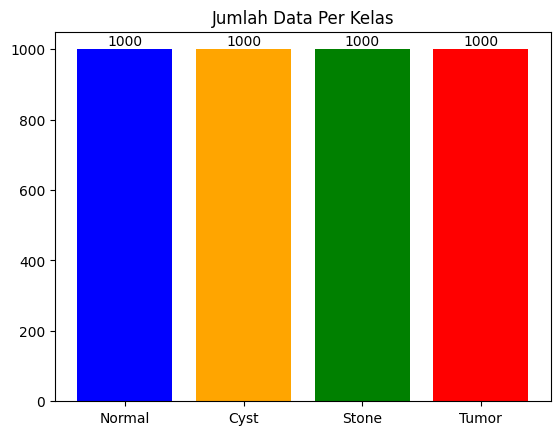

In [7]:
# Gabungkan label dan path dalam satu Dictionary
data_folders = {
  "Normal": "/content/Dataset_Subset_1000/Cyst",
  "Cyst": "/content/Dataset_Subset_1000/Normal",
  "Stone": "/content/Dataset_Subset_1000/Stone",
  "Tumor": "/content/Dataset_Subset_1000/Tumor"
}

# Hitung jumlah file sekaligus ambil nama kategorinya
labels = list(data_folders.keys())
counts = [len(os.listdir(p)) for p in data_folders.values()]

# Tampilkan Grafik
plt.bar(labels, counts, color=['blue', 'orange', 'green', 'red'])
plt.title("Jumlah Data Per Kelas")

# Tambahkan angka di atas setiap batang agar jelas
for i, v in enumerate(counts):
  plt.text(i, v+10, str(v), ha='center')

plt.show()

Found 3200 images belonging to 4 classes.
Found 800 images belonging to 4 classes.

Image data generators created successfully.
Training images: 3200
Validation images: 800


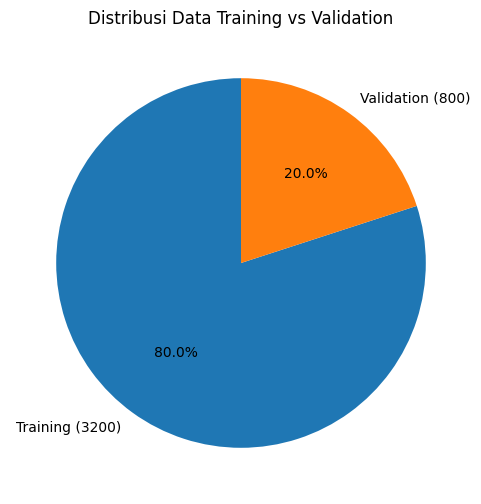

In [8]:
# Mengubah semua gambar dengan ukuran 224x224 piksel
IMG_HEIGHT = 224
IMG_WIDTH = 224
# Model belajar dari 32 gambar per satu langkah pelatihan
BATCH_SIZE = 32 # Hyperparameter

# Membuat data "tiruan" yang bervariasi dari data asli
train_datagen = ImageDataGenerator(
  # Mengubah nilai setiap piksel (0-255) menjadi rentang 0 hingga 1# Mengubah nilai setiap piksel (0-255) menjadi rentang 0 hingga 1
  preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
  # Memutar dan menggeser gambar secara horizontal/vertikal.
  rotation_range=40,
  width_shift_range=0.2,
  height_shift_range=0.2,
  # Memberikan efek miring (distorsi) dan memperbesar/memperkecil gambar secara acak
  shear_range=0.2,
  zoom_range=0.2,
  # Membalik gambar secara horizontal (seperti cermin)
  horizontal_flip=True,
  # Mengubah tingkat kecerahan gambar (dari redup hingga terang)
  brightness_range=[0.5, 1.5],
  # Jika saat diputar ada bagian kosong di pojok gambar.
  fill_mode='nearest',
  # 20% for validation
  validation_split=0.2
)

# Data validasi tidak diberikan augmentasi (seperti rotasi atau flip)
validation_datagen = ImageDataGenerator(
  # Data validasi hanya di rescale saja
  # rescale=1./255,
  preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
  validation_split=0.2
  # 20% data untuk validation
  # 80% data untuk training
)

# Bagian ini menghubungkan kode dengan folder di drive
train_generator = train_datagen.flow_from_directory(
  subset_dir, # Folder sumber diisi dengan 1000 gambar per kelas
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='categorical', # Digunakan karena label memiliki 4 kelas
  subset='training',
  # Training: Mengambil 80% data untuk belajar
  # Validation: Mengambil 20% sisanya untuk ujian tengah semester model
  seed=42 # Memastikan pembagian data selalu sama setiap kali kode dijalankan
)

# Muat gambar dari parent_dir untuk validasi
validation_generator = validation_datagen.flow_from_directory(
  subset_dir,
  target_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE,
  class_mode='categorical',
  subset='validation',
  seed=42
)

print("\nImage data generators created successfully.")
print(f"Training images: {train_generator.samples}")
print(f"Validation images: {validation_generator.samples}")

# 1. Ambil jumlah data dari generator
counts = [train_generator.samples, validation_generator.samples]
labels = [f'Training ({counts[0]})', f'Validation ({counts[1]})']

# 2. Plot diagram lingkaran (Pie Chart)
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribusi Data Training vs Validation")
plt.show()

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# Ambil semua path file dan label dari subset_dir (yang berisi 1000 per kelas)
filenames = []
labels = []

# Membaca folder kategori (Class)
for category in os.listdir(subset_dir):
    # Membuat alamat lengkap folder
    category_path = os.path.join(subset_dir, category)
    # Memastikan itu adalah folder
    if os.path.isdir(category_path):
        # Mendata setiap file gambar
        for file in os.listdir(category_path):
            filenames.append(os.path.join(category_path, file))
            labels.append(category)

# Membuat tabel (DataFrame)
df = pd.DataFrame({'filename': filenames, 'label': labels})

# Pembagian: 70% Train, 30% Sisanya (untuk Val + Test)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
# Pembagian Sisa (30%) menjadi dua: 15% Val dan 15% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"Training Images: {len(train_df)}")
print(f"Validation Images: {len(val_df)}")
print(f"Testing Images: {len(test_df)}")

Training Images: 2800
Validation Images: 600
Testing Images: 600


Found 2800 validated image filenames belonging to 4 classes.
Found 600 validated image filenames belonging to 4 classes.
Found 600 validated image filenames belonging to 4 classes.


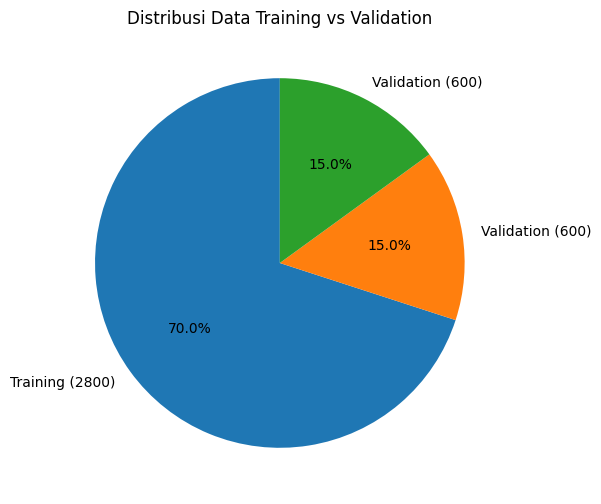

In [10]:
# Gunakan parameter augmentasi yang sudah kamu definisikan di train_datagen sebelumnya
# Gunakan rescale saja untuk val dan test

# 1. Train Generator (70%)
train_generator = train_datagen.flow_from_dataframe(
  train_df,
  x_col='filename',
  y_col='label',
  target_size=(IMG_WIDTH, IMG_HEIGHT),
  batch_size=BATCH_SIZE,
  class_mode='categorical'
)

# 2. Validation Generator (15%)
validation_generator = validation_datagen.flow_from_dataframe(
  val_df,
  x_col='filename',
  y_col='label',
  target_size=(IMG_WIDTH, IMG_HEIGHT),
  batch_size=BATCH_SIZE,
  class_mode='categorical'
)

# 3. Test Generator (15%) - Gunakan validation_datagen karena hanya butuh rescale
test_generator = validation_datagen.flow_from_dataframe(
  test_df,
  x_col='filename',
  y_col='label',
  target_size=(IMG_WIDTH, IMG_HEIGHT),
  batch_size=BATCH_SIZE,
  class_mode='categorical',
  shuffle=False # Agar urutan hasil prediksi nanti mudah dicek
)

# 1. Ambil jumlah data dari generator
counts = [train_generator.samples, validation_generator.samples, test_generator.samples]
labels = [f'Training ({counts[0]})', f'Validation ({counts[1]})', f'Validation ({counts[2]})']

# 2. Plot diagram lingkaran (Pie Chart)
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribusi Data Training vs Validation")
plt.show()

In [ ]:
# Hitung jumlah data per kelas di masing-masing split
train_counts = train_df['label'].value_counts().sort_index()
val_counts = val_df['label'].value_counts().sort_index()
test_counts = test_df['label'].value_counts().sort_index()

# Siapkan Data untuk Plotting
categories = train_counts.index
df_plot = pd.Dataframe({
  "Train (70%)": train_counts,
  "Validation (15%)": val_counts,
  "Test (15%)": test_counts
})

# Membuat Bar Chart
ax = df_plot.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF9800', '#2196F3'])
plt.title("Distribusi Kelas pada Tiap Split (Stratified)", fontsize=14)
plt.xlabel("Kategori Penyakit Ginjal", fontsize=12)
plt.ylabel("Jumlah Gambar", fontsize=12)
plt.legend(title="Pembagian Data")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan label angka di atas setiap bar
for i, total in enumerate(df_plot.sum(axis=1)):
  ax.text(i, total + 5, int(total), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
# 1. Definisikan Fungsi Pembuat Model
def build_efficientnet_model():
  # Memuat Base Model (EfficientNetB0)
  base_model = EfficientNetB0(
      weights='imagenet',
      include_top=False,
      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
  )

  # Membekukan bobot dasar agar tidak berubah saat training awal
  base_model.trainable = False

  # Menyusun Arsitektur Sequential
  model = models.Sequential([
      base_model,
      layers.GlobalAveragePooling2D(),
      layers.Dense(256, activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.3),
      layers.Dense(4, activation='softmax') # 4 Kelas: Normal, Cyst, Tumor, Stone
  ])

  # Kompilasi Model
  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )
  return model

# 2. Panggil Fungsi untuk Membuat Model
efficientNet_model = build_efficientnet_model()

# 3. Tampilkan Ringkasan Arsitektur (Model Summary)
# Ini akan menampilkan jumlah parameter dan urutan layer secara detail
efficientNet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,559 (16.71 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [18]:
# 4. Mulai Proses Pelatihan
history = efficientNet_model.fit(
  train_generator,
  epochs=20,
  validation_data=validation_generator,
  verbose=1
)

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 323s 4s/step - accuracy: 0.6502 - loss: 0.9518 - val_accuracy: 0.7900 - val_loss: 0.5523
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 328s 4s/step - accuracy: 0.8481 - loss: 0.4022 - val_accuracy: 0.8850 - val_loss: 0.3710
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 331s 4s/step - accuracy: 0.8767 - loss: 0.3337 - val_accuracy: 0.8367 - val_loss: 0.4215
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 362s 4s/step - accuracy: 0.9193 - loss: 0.2194 - val_accuracy: 0.7700 - val_loss: 0.6514
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 404s 4s/step - accuracy: 0.9172 - loss: 0.2307 - val_accuracy: 0.8117 - val_loss: 0.5015
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 388s 4s/step - accuracy: 0.9168 - loss: 0.2234 - val_accuracy: 0.8450 - val_loss: 0.4021
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.9297 - loss: 0.1865 - val_accuracy: 0.8700 - val_loss: 0.3194
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 328s 4s/step - accuracy: 0.9226 - loss: 0.2156 - val_accuracy: 0.8583 - v

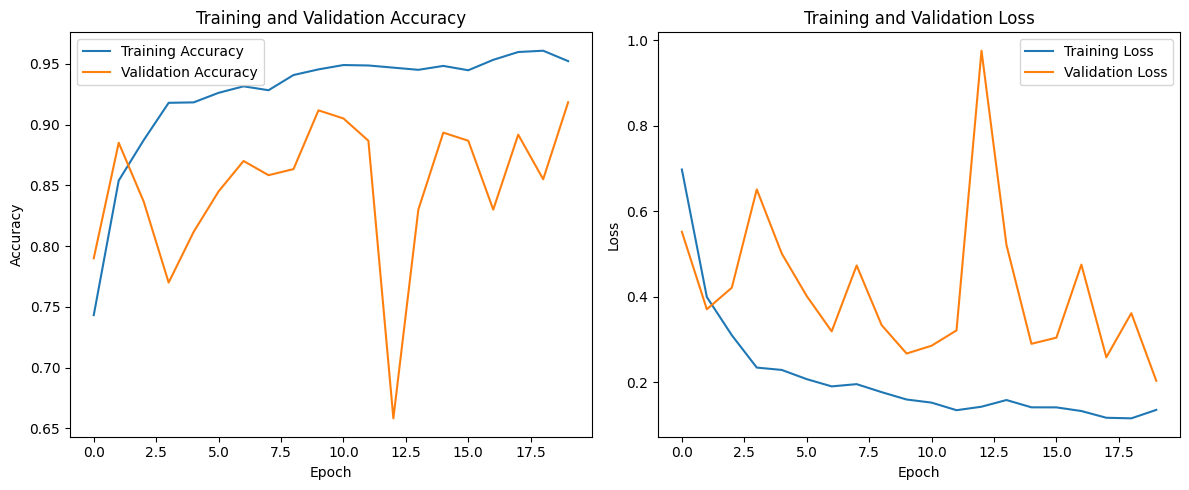

In [19]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
import time
import numpy as np
from sklearn.metrics import accuracy_score

# --- Mulai hitung waktu ---
start_time = time.time()

# 1. Ambil prediksi dari model
Y_pred = efficientNet_model.predict(test_generator)

# --- Selesai hitung waktu ---
end_time = time.time()
inference_time = end_time - start_time

# Mengubah probabilitas menjadi label kelas
y_pred = np.argmax(Y_pred, axis=1)

# 2. Ambil label asli dari generator
y_true = test_generator.classes

# 3. Hitung Akurasi Testing
test_accuracy = accuracy_score(y_true, y_pred)

# --- Tampilkan Hasil ---
print(f"--- Hasil Evaluasi Data Test ---")
print(f"Akurasi Testing : {test_accuracy:.2f}")
print(f"Total Waktu Prediksi : {inference_time:.4f} detik")
print(f"Rata-rata per Gambar : {inference_time / len(y_true):.4f} detik/gambar")

19/19 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step
--- Hasil Evaluasi Data Test ---
Akurasi Testing : 0.9116666666666666%
Total Waktu Prediksi : 55.0476 detik
Rata-rata per Gambar : 0.0917 detik/gambar


In [24]:
# 2. Menampilkan Classification Report
# Ini akan menunjukkan Precision, Recall, dan F1-Score untuk setiap jenis penyakit ginjal
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
classification_report = classification_report(y_true, y_pred, target_names=class_labels)
print(classification_report)


--- Classification Report ---
              precision    recall  f1-score   support

        Cyst       0.94      0.99      0.97       150
      Normal       1.00      0.75      0.85       150
       Stone       0.77      1.00      0.87       150
       Tumor       1.00      0.91      0.95       150

    accuracy                           0.91       600
   macro avg       0.93      0.91      0.91       600
weighted avg       0.93      0.91      0.91       600




--- Confusion Matrix ---


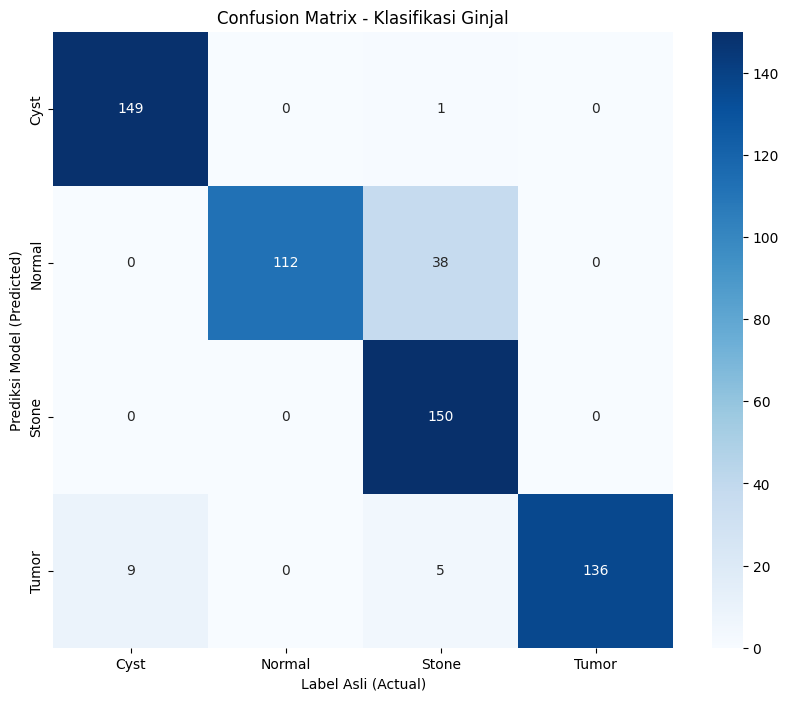

In [25]:
# 3. Membuat Confusion Matrix (Visual)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Klasifikasi Ginjal')
plt.xlabel('Label Asli (Actual)')
plt.ylabel('Prediksi Model (Predicted)')
plt.show()

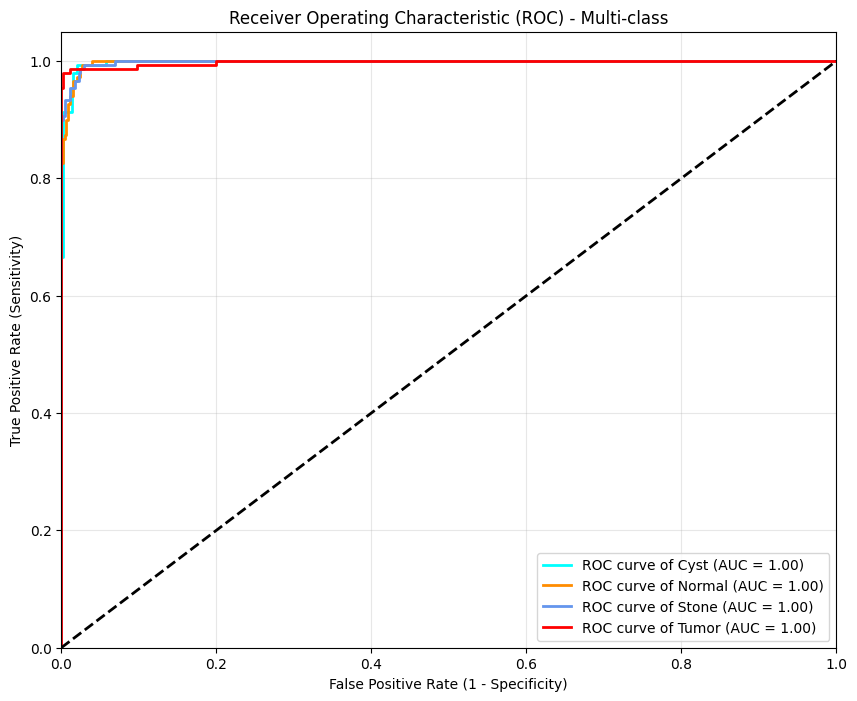

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# 1. Persiapan Data
# Pastikan Y_pred adalah output probabilitas dari model.predict(test_generator)
# y_true adalah label asli dari test_generator.classes
n_classes = len(class_labels)

# Binarize label asli (misal: 2 menjadi [0, 0, 1, 0])
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

# 2. Hitung ROC dan AUC untuk setiap kelas
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Plot Kurva ROC
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_labels[i]} (AUC = {roc_auc[i]:.2f})')

# Plot garis bantu diagonal (random guess)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - Multi-class')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [40]:
def predict_single_image(img_path, model, class_indices):
  # 1. Load dan Preprocess Gambar
  img = image.load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
  img_array = image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)

  # Preprocessing EfficientNet (Wajib)
  img_preprocessed = tf.keras.applications.efficientnet.preprocess_input(img_array)

  # 2. Prediksi
  predictions = model.predict(img_preprocessed)[0]

  # 3. Menggabungkan Nama Kelas dan Persentase Hasil
  class_names = list(class_indices.keys())

  # Mengurutkan hasil dari persentase tertinggi ke terendah (Opsional, agar rapi seperti contoh)
  results = []
  for i in range(len(class_names)):
    results.append((class_names[i], predictions[i] * 100))

  # Sort berdasarkan persentase (index 1) secara descending
  results.sort(key=lambda x: x[1], reverse=True)

  # Menyusun teks untuk ditampilkan DI ATAS gambar
  display_text = "Predictions\n"
  for class_name, percentage in results:
    display_text += f"Class: {class_name}, Prediction : {percentage:.2f}%\n"

  # 4. Visualisasi
  plt.figure(figsize=(3, 5)) # Ukuran disesuaikan agar teks dan gambar muat

  # Menampilkan teks di posisi atas (menggunakan plt.text atau suptitle)
  plt.text(0.5, 1.05, display_text, horizontalalignment='center',
           verticalalignment='bottom', transform=plt.gca().transAxes, fontsize=12)

  plt.imshow(img)
  plt.axis('off')
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


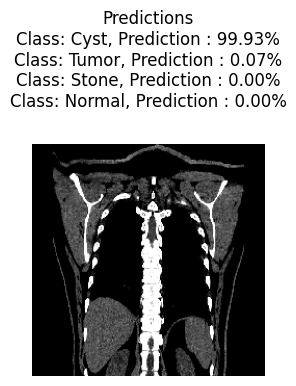

In [41]:
# Panggil fungsi
image_to_predict_path1 = "/content/Sample_Data/Cyst- (3709).jpg"
predict_single_image(image_to_predict_path1, efficientNet_model, train_generator.class_indices)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


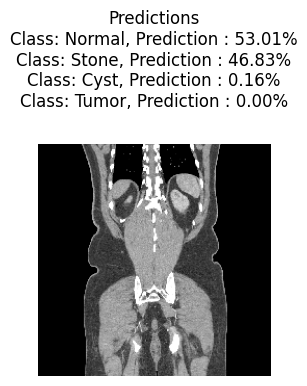

In [42]:
image_to_predict_path2 = "/content/Sample_Data/Normal- (5077).jpg"
predict_single_image(image_to_predict_path2, efficientNet_model, train_generator.class_indices)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


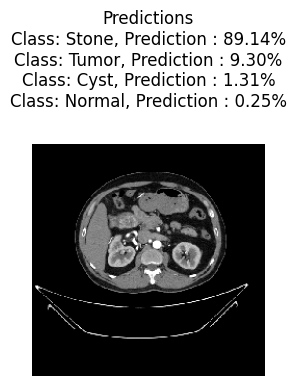

In [47]:
image_to_predict_path3 = "/content/Sample_Data/Tumor- (10).jpg"
predict_single_image(image_to_predict_path3, efficientNet_model, train_generator.class_indices)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 767ms/step


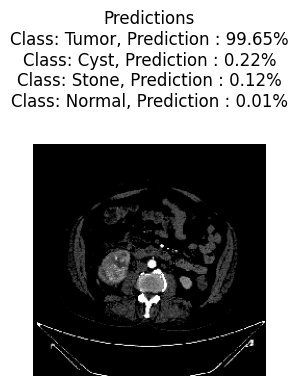

In [48]:
image_to_predict_path4 = "/content/Sample_Data/Tumor- (1).jpg"
predict_single_image(image_to_predict_path4, efficientNet_model, train_generator.class_indices)